# Projeto Machine Learning | Spotify Tracks

### Entendimento e pré‑processamento dos dados

### Análise exploratória (EDA)

### Definição do problema de ML

### Construção do modelo

In [62]:
import kagglehub
import os
import pandas as pd
pd.set_option('display.max_columns', None)

# Download latest version
path = kagglehub.dataset_download("amitanshjoshi/spotify-1million-tracks")

# Filtro das colunas que usaremos somente
usecols = ['artist_name', 'track_name', 'track_id', 'popularity', 'genre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# O estudo será baseado apenas em gêneros de rock
genre_rock = ['alt-rock', 'black-metal', 'death-metal', 'emo', 'hard-rock', 'hardcore', 'heavy-metal', 'metal', 'metalcore', 
              'goth', 'classical', 'psych-rock', 'punk', 'punk-rock', 'rock', 'rock-n-roll']

# Exemplo de como criar filtros como variáveis e aplicá-los depois no DataFrame

df = pd.read_csv(os.path.join(path, "spotify_data.csv"), usecols=usecols, low_memory=False)

# Somente generos de rock
filtro_rock = df['genre'].isin(genre_rock)
#Somente musicas com popularidade maior que 30, para eliminar musicas muito desconhecidas
filtro_popularidade = df['popularity'] > 1
# Somente musicas com instrumentalidade maior que 0.5, para eliminar podcasts
filtro_instrumentalness = df['instrumentalness'] > 0.2




df = df[filtro_rock]
df = df[filtro_instrumentalness]
df = df[filtro_popularidade]


C:\Users\caioc\AppData\Local\Temp\ipykernel_15392\1815015496.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[filtro_instrumentalness]
C:\Users\caioc\AppData\Local\Temp\ipykernel_15392\1815015496.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[filtro_popularidade]


In [63]:
df[df['artist_name'].str.contains('Saos', na=False)]

,artist_name,track_name,track_id,popularity,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
904712,Saosin,It's So Simple,4amcY5vhp2Z40EhNVa2xHl,45,hardcore,0.312,0.943,6,-3.368,0,0.0554,0.000048,0.378,0.2370,0.504,199.981
1051743,Saosin,Exfoliator (Inst. Demo),4j3MdHoItSODdoHlsB7Yjh,17,metalcore,0.384,0.656,8,-10.783,1,0.0321,0.000214,0.626,0.1450,0.336,167.014
1051748,Saosin,Write Something Heavy and Fast ( Inst. Demo),4HFd9wmkqCldcHPAU0CDS0,17,metalcore,0.173,0.775,0,-10.293,1,0.0462,0.002350,0.732,0.2240,0.219,194.974
1051750,Saosin,Brikka Brikka (Inst. Demo),5VzCaU6zcQY1x22QBOm4cX,16,metalcore,0.213,0.845,5,-11.902,1,0.0455,0.000201,0.656,0.2640,0.285,93.505
1051754,Saosin,The Alarming Sound (Inst. Demo),2xV1mZ4yNbEnQdi1wNoc8r,17,metalcore,0.562,0.606,9,-11.687,0,0.0309,0.000942,0.599,0.0849,0.336,120.058


# Visualização do Dados

===== Overview =====
Shape: 1159764 rows x 16 cols
Memory: 429.62 MB

===== Dtypes =====
acousticness        float64
artist_name          object
danceability        float64
energy              float64
genre                object
instrumentalness    float64
key                   int64
liveness            float64
loudness            float64
mode                  int64
popularity            int64
speechiness         float64
tempo               float64
track_id             object
track_name           object
valence             float64
dtype: object

===== Head =====
     artist_name        track_name                track_id  popularity  \
0     Jason Mraz   I Won't Give Up  53QF56cjZA9RTuuMZDrSA6          68   
1     Jason Mraz  93 Million Miles  1s8tP3jP4GZcyHDsjvw218          50   
2  Joshua Hyslop  Do Not Let Me Go  7BRCa8MPiyuvr2VU3O9W0F          57   
3   Boyce Avenue          Fast Car  63wsZUhUZLlh1OsyrZq7sz          58   
4   Andrew Belle  Sky's Still Blue  6nXIYClvJAfi6ujLiKqEq8   

c:\Users\caioc\OneDrive\Documentos\Pós Graduação - PUC\Sprint 3 - Machine Learning\mvp-machine-learning-spotify-tracks\utils\quick_eda.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\caioc\OneDrive\Documentos\Pós Graduação - PUC\Sprint 3 - Machine Learning\mvp-machine-learning-spotify-tracks\utils\quick_eda.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\caioc\OneDrive\Documentos\Pós Graduação - PUC\Sprint 3 - Machine Learning\mvp-machine-learning-spotify-tracks\utils\quick_eda.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\caioc\OneDrive\Documentos\Pós Graduação - PUC\Sprint 3 - Machine Learning\mvp-machine-learning-spotify-tracks\utils\quick_eda.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


EDA complete. Figures:
missing, num_hist, num_box, corr_heatmap, cat_bars


c:\Users\caioc\OneDrive\Documentos\Pós Graduação - PUC\Sprint 3 - Machine Learning\mvp-machine-learning-spotify-tracks\utils\quick_eda.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


{'missing': <Figure size 800x400 with 1 Axes>,
 'num_hist': <Figure size 1200x1200 with 12 Axes>,
 'num_box': <Figure size 640x500 with 1 Axes>,
 'corr_heatmap': <Figure size 580x580 with 2 Axes>,
 'cat_bars': <Figure size 900x350 with 2 Axes>}

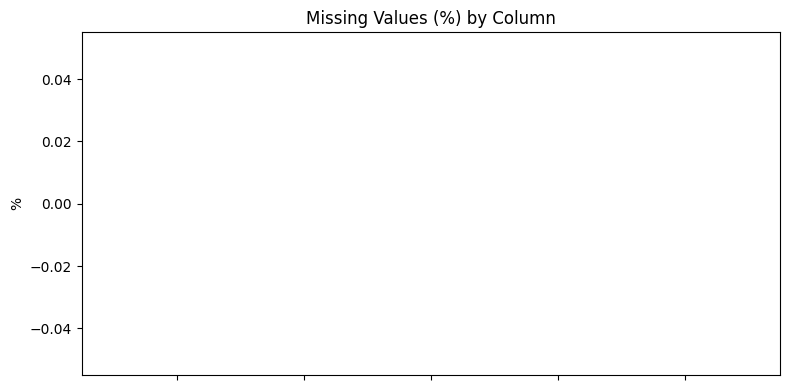

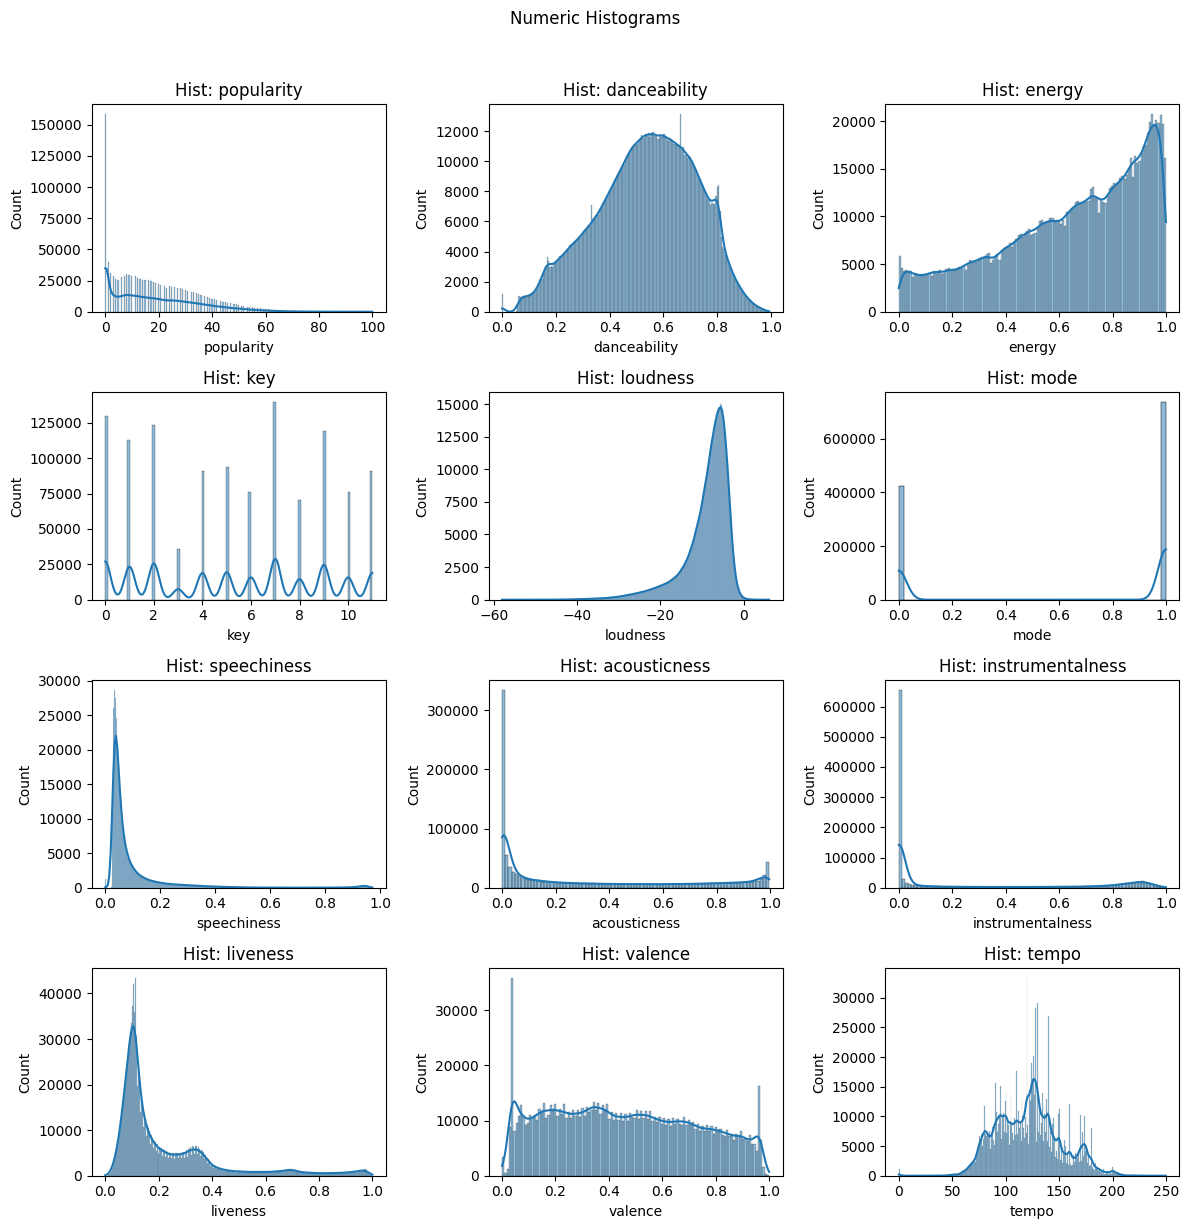

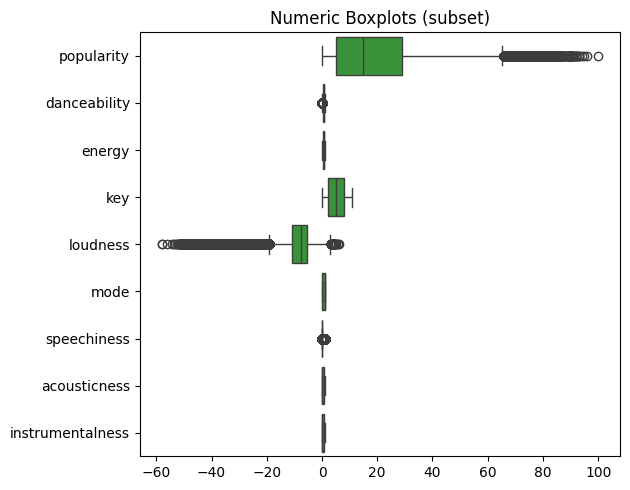

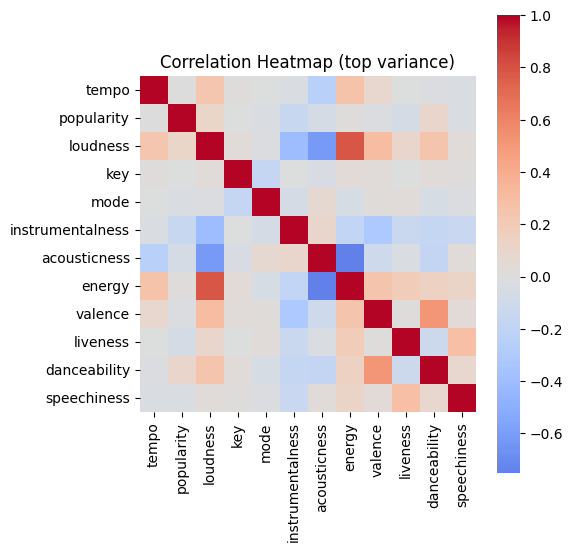

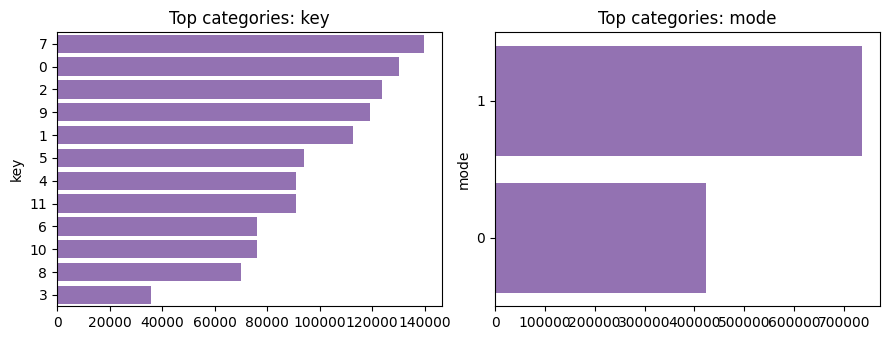

In [19]:
from utils.quick_eda import profile_df
profile_df(df)